# Step 1: Import Libraries and Load CIFAR-10 Dataset

In [1]:
!pip uninstall -y sympy
!pip install sympy==1.13.1

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 53.2 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires sympy>=1.13.3, but you have sympy 1.13.1 which is incompatible.


In [2]:
# =========================================================
# Step 1: Import Required Libraries and Load CIFAR-10 Dataset
# =========================================================

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# ---------------------------------------------------------
# Define image preprocessing transformations
#
# 1. Convert images to PyTorch tensors
# 2. Normalize pixel values to improve training stability
#
# CIFAR-10 images are RGB images of size 32x32
# ---------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),

    # Normalize RGB channels
    # (mean = 0.5, std = 0.5 for each channel)
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# ---------------------------------------------------------
# Load CIFAR-10 Training Dataset
#
# train=True → loads training split (50,000 images)
# download=True → downloads dataset if not already present
# ---------------------------------------------------------

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# ---------------------------------------------------------
# Create Training DataLoader
#
# batch_size → number of images per batch
# shuffle=True → randomize data for better learning
# num_workers=2 → parallel loading for faster training
#
# NOTE:
# Using batch_size=64 instead of 4 for faster training
# and better GPU utilization in Kaggle notebooks
# ---------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

# ---------------------------------------------------------
# Load CIFAR-10 Test Dataset
#
# train=False → loads test split (10,000 images)
# ---------------------------------------------------------

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# ---------------------------------------------------------
# Create Test DataLoader
#
# shuffle=False → preserve order during evaluation
# ---------------------------------------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

# ---------------------------------------------------------
# CIFAR-10 Class Labels
# These are the 10 output classes for classification
# ---------------------------------------------------------

classes = (
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

# ---------------------------------------------------------
# Quick sanity check
# ---------------------------------------------------------

print("Training samples:", len(train_dataset))
print("Testing samples :", len(test_dataset))
print("Classes         :", classes)

100%|██████████| 170M/170M [00:03<00:00, 52.2MB/s] 


Training samples: 50000
Testing samples : 10000
Classes         : ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


# Step 2: Visualize Sample Images from the CIFAR-10 Dataset

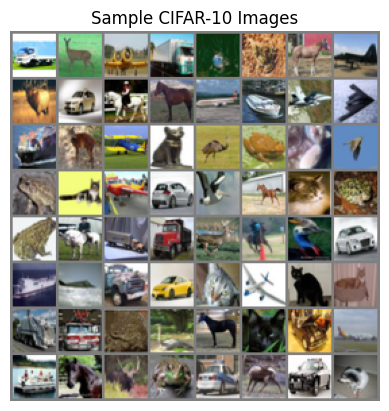

Labels:
truck | deer | plane | truck | frog | frog | horse | plane | 

In [3]:
# =========================================================
# Step 2: Visualize Sample Images from CIFAR-10
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
import torchvision

# ---------------------------------------------------------
# Function to display images
#
# Since we normalized the images earlier using:
# Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
#
# we need to reverse (unnormalize) that step before
# displaying them properly.
# ---------------------------------------------------------

def imshow(img):
    """
    Display an image using matplotlib.

    Parameters:
    img : torch.Tensor
        Image tensor in shape (C, H, W)
    """

    # Unnormalize the image
    img = img / 2 + 0.5

    # Convert tensor to NumPy array
    np_img = img.numpy()

    # Change shape from (C, H, W) → (H, W, C)
    plt.imshow(np.transpose(np_img, (1, 2, 0)))

    plt.title("Sample CIFAR-10 Images")
    plt.axis("off")
    plt.show()


# ---------------------------------------------------------
# Get a batch of random training images
# ---------------------------------------------------------

data_iterator = iter(train_loader)

# Fetch one batch
images, labels = next(data_iterator)

# ---------------------------------------------------------
# Display images in grid format
#
# torchvision.utils.make_grid() combines multiple images
# into one visual grid for easier viewing
# ---------------------------------------------------------

imshow(torchvision.utils.make_grid(images))

# ---------------------------------------------------------
# Print corresponding class labels
# ---------------------------------------------------------

print("Labels:")

for i in range(8):  # showing first 8 labels from batch
    print(f"{classes[labels[i]]}", end=" | ")

In [4]:
from collections import Counter

label_counts = Counter(train_dataset.targets)
print(label_counts)

Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})


# Step 3: Defining the Custom Prunable Linear Layer

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [17]:
# =========================================================
# Step 3: Define the Custom Prunable Linear Layer
# (Improved Version with Better Gate Initialization)
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class PrunableLinear(nn.Module):
    """
    Custom Linear Layer with Learnable Gates

    Each weight has:
        1. Normal trainable weight
        2. Learnable gate score

    Gate values are computed using:

        gate = sigmoid(gate_score)

    Final effective weight:

        effective_weight = weight * gate

    This allows the network to learn which
    connections should remain active and
    which should be pruned automatically.
    """

    def __init__(self, in_features, out_features):
        """
        Parameters:
        in_features  : Number of input neurons
        out_features : Number of output neurons
        """

        super().__init__()

        # -------------------------------------------------
        # Standard trainable weights
        #
        # Shape:
        # (out_features, in_features)
        # -------------------------------------------------

        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.01
        )

        # -------------------------------------------------
        # Standard trainable bias
        # -------------------------------------------------

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

        # -------------------------------------------------
        # Learnable Gate Scores
        #
        # IMPORTANT IMPROVEMENT:
        #
        # Instead of random initialization:
        #
        #     torch.randn(...)
        #
        # we initialize with:
        #
        #     -2.0
        #
        # because:
        #
        # sigmoid(-2) ≈ 0.12
        #
        # This helps pruning happen more naturally.
        #
        # If initialized near 0:
        #
        # sigmoid(0) = 0.5
        #
        # then almost all gates start too active,
        # making pruning much harder.
        # -------------------------------------------------

        self.gate_scores = nn.Parameter(
            torch.ones(out_features, in_features) * -1.5
        )

    def forward(self, x):
        """
        Forward Pass

        Steps:
        1. Convert gate scores → gate values using sigmoid
        2. Multiply weights by gates
        3. Apply linear transformation

        Final:

            y = x(W * gate) + bias
        """

        # Convert gate scores to values between 0 and 1
        gates = torch.sigmoid(self.gate_scores)

        # Apply pruning effect
        pruned_weights = self.weight * gates

        # Standard linear transformation
        return F.linear(x, pruned_weights, self.bias)

# Step 4 : Building the Self-Pruning Neural Network


In [19]:
# =========================================================
# Step 4: CNN + Self-Pruning Hybrid Network
# =========================================================


class PrunableNet(nn.Module):
    """
    CNN + Self-Pruning Fully Connected Layers

    Architecture:

    Input Image (3x32x32)

        ↓

    Conv2D (3 → 32)
        ↓
    ReLU
        ↓
    MaxPool

        ↓

    Conv2D (32 → 64)
        ↓
    ReLU
        ↓
    MaxPool

        ↓

    Flatten

        ↓

    PrunableLinear
        ↓
    BatchNorm
        ↓
    ReLU

        ↓

    PrunableLinear
        ↓
    Output Layer

    Final output:
        10 classes for CIFAR-10
    """

    def __init__(self):
        super().__init__()

        # -------------------------------------------------
        # Convolution Layer 1
        #
        # Input:
        # (3, 32, 32)
        #
        # Output:
        # (32, 32, 32)
        # -------------------------------------------------

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # -------------------------------------------------
        # Convolution Layer 2
        #
        # Output:
        # (64, 16, 16)
        # after pooling
        # -------------------------------------------------

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # -------------------------------------------------
        # Max Pooling
        # reduces spatial dimensions by 2
        # -------------------------------------------------

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # -------------------------------------------------
        # After 2 poolings:
        #
        # 32x32 → 16x16 → 8x8
        #
        # Final shape:
        # (64, 8, 8)
        #
        # Flattened:
        # 64 * 8 * 8 = 4096
        # -------------------------------------------------

        self.fc1 = PrunableLinear(
            in_features=64 * 8 * 8,
            out_features=512
        )

        self.bn1 = nn.BatchNorm1d(512)

        # -------------------------------------------------
        # Final Output Layer
        # -------------------------------------------------

        self.fc2 = PrunableLinear(
            in_features=512,
            out_features=10
        )

    def forward(self, x):
        """
        Forward pass
        """

        # -------------------------------------------------
        # Conv Block 1
        # -------------------------------------------------

        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)

        # -------------------------------------------------
        # Conv Block 2
        # -------------------------------------------------

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        # -------------------------------------------------
        # Flatten
        #
        # (batch, 64, 8, 8)
        # →
        # (batch, 4096)
        # -------------------------------------------------

        x = x.view(x.size(0), -1)

        # -------------------------------------------------
        # Prunable FC Layer
        # -------------------------------------------------

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)

        # -------------------------------------------------
        # Output Layer
        # -------------------------------------------------

        x = self.fc2(x)

        return x

    def get_all_gates(self):
        """
        Collect gate values from all prunable layers
        """

        gates = []

        for module in self.modules():
            if isinstance(module, PrunableLinear):
                gates.append(
                    torch.sigmoid(module.gate_scores)
                )

        return gates

# Step 5: Visualize the Network Architecture

In [20]:
# =========================================================
# Step 5: Visualize the Network Architecture
# =========================================================

# Create model instance
model = PrunableNet()

# Print full model architecture
print(model)

PrunableNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): PrunableLinear()
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): PrunableLinear()
)


In [21]:
# Count total trainable parameters

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 4,225,482


# Step 6: Define the Sparsity Loss (L1 Regularization on Gates)

In [22]:
# =========================================================
# Step 5: Define Sparsity Loss
# =========================================================

import torch.nn as nn

# ---------------------------------------------------------
# Standard classification loss
#
# Since CIFAR-10 is a multi-class classification problem,
# CrossEntropyLoss is the correct choice
# ---------------------------------------------------------

criterion = nn.CrossEntropyLoss()


def compute_sparsity_loss(model):
    """
    Compute L1 Sparsity Loss using all gate values

    Formula:

        Sparsity Loss = sum(all gate values)

    Since:

        gate = sigmoid(gate_scores)

    and sigmoid outputs values between 0 and 1,

    minimizing this loss pushes gates toward zero,
    which effectively prunes unnecessary weights.
    """

    sparsity_loss = 0.0

    # Loop through all PrunableLinear layers
    for gates in model.get_all_gates():

        # Since gates are always positive,
        # L1 norm becomes simple summation
        sparsity_loss += gates.sum()

    return sparsity_loss

In [23]:
model = PrunableNet()

loss = compute_sparsity_loss(model)

print("Initial Sparsity Loss:", loss.item())

Initial Sparsity Loss: 383508.0625


In [108]:
# =========================================================
# Step 6: Setup Device and Optimizer
# =========================================================

import torch.optim as optim

# ---------------------------------------------------------
# Select device
#
# If GPU is available in Kaggle:
#     use CUDA
#
# Otherwise:
#     use CPU
# ---------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

# ---------------------------------------------------------
# Create model instance
# and move it to selected device
# ---------------------------------------------------------

model = PrunableNet().to(device)

# ---------------------------------------------------------
# Optimizer
#
# Adam is used for:
# - stable learning
# - better convergence
# - smoother gate optimization
#
# lr = 1e-4 is the best practical choice here
# ---------------------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
    
)

# ---------------------------------------------------------
# Initial lambda value
#
# Controls sparsity strength
#
# Start with:
# lambda = 1e-3
#
# Later we will compare multiple values
# ---------------------------------------------------------

lambda_val = 1e-4

print(f"Initial Lambda Value: {lambda_val}")

Using device: cuda
Initial Lambda Value: 0.0001


# Step 7: Train the Self-Pruning Neural Network

In [117]:
# =========================================================
# Step 7: Training Loop
# =========================================================

# Number of complete passes through the training dataset
epochs = 30


# Set model to training mode
model.train()

for epoch in range(epochs):

    # Track total loss for this epoch
    total_loss_epoch = 0.0

    # -----------------------------------------------------
    # Loop through training batches
    # -----------------------------------------------------

    for inputs, targets in train_loader:

        # Move data to GPU/CPU
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # ---------------------------------------------
        # Forward pass
        # ---------------------------------------------

        outputs = model(inputs)

        # ---------------------------------------------
        # Classification Loss
        # ---------------------------------------------

        cls_loss = criterion(outputs, targets)

        # ---------------------------------------------
        # Sparsity Loss
        # ---------------------------------------------

        sparsity_loss = compute_sparsity_loss(model)

        # ---------------------------------------------
        # Total Loss
        # ---------------------------------------------

        total_loss = (
            cls_loss
            + lambda_val * sparsity_loss
        )

        # ---------------------------------------------
        # Backpropagation
        # ---------------------------------------------

        total_loss.backward()
        optimizer.step()

        # Add batch loss to epoch total
        total_loss_epoch += total_loss.item()

    # -----------------------------------------------------
    # Print progress after each epoch
    # -----------------------------------------------------

    print(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Total Loss: {total_loss_epoch:.2f}"
    )

Epoch [1/30] | Total Loss: 5908.42
Epoch [2/30] | Total Loss: 5646.61
Epoch [3/30] | Total Loss: 5398.38
Epoch [4/30] | Total Loss: 5159.30
Epoch [5/30] | Total Loss: 4926.82
Epoch [6/30] | Total Loss: 4704.56
Epoch [7/30] | Total Loss: 4496.53
Epoch [8/30] | Total Loss: 4296.29
Epoch [9/30] | Total Loss: 4119.81
Epoch [10/30] | Total Loss: 3951.83
Epoch [11/30] | Total Loss: 3786.63
Epoch [12/30] | Total Loss: 3621.19
Epoch [13/30] | Total Loss: 3458.64
Epoch [14/30] | Total Loss: 3306.67
Epoch [15/30] | Total Loss: 3171.34
Epoch [16/30] | Total Loss: 3040.20
Epoch [17/30] | Total Loss: 2908.92
Epoch [18/30] | Total Loss: 2800.56
Epoch [19/30] | Total Loss: 2699.06
Epoch [20/30] | Total Loss: 2594.79
Epoch [21/30] | Total Loss: 2485.70
Epoch [22/30] | Total Loss: 2380.02
Epoch [23/30] | Total Loss: 2289.15
Epoch [24/30] | Total Loss: 2199.78
Epoch [25/30] | Total Loss: 2106.53
Epoch [26/30] | Total Loss: 2021.61
Epoch [27/30] | Total Loss: 1948.41
Epoch [28/30] | Total Loss: 1875.19
E

# Step 8: Evaluate Model Accuracy and Sparsity

In [118]:
# =========================================================
# Step 8: Evaluate Accuracy and Sparsity
# =========================================================


def compute_sparsity(model, threshold=1e-2):
    """
    Compute percentage of pruned connections

    A connection is considered pruned if:

        gate < threshold

    Default threshold:
        0.01
    """

    total_gates = 0
    pruned_gates = 0

    # Loop through all PrunableLinear layers
    for module in model.modules():

        if isinstance(module, PrunableLinear):

            # Convert gate scores to actual gate values
            gates = torch.sigmoid(module.gate_scores)

            # Total number of gates
            total_gates += gates.numel()

            # Count gates smaller than threshold
            pruned_gates += (gates < threshold).sum().item()

    sparsity_percentage = (
        pruned_gates / total_gates
    ) * 100

    return sparsity_percentage


def evaluate(model, test_loader, device):
    """
    Compute classification accuracy on test dataset
    """

    # Set model to evaluation mode
    model.eval()

    correct = 0
    total = 0

    # Disable gradient computation
    with torch.no_grad():

        for inputs, targets in test_loader:

            # Move data to device
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Forward pass
            outputs = model(inputs)

            # Get predicted class
            _, predicted = torch.max(outputs, 1)

            total += targets.size(0)
            correct += (
                predicted == targets
            ).sum().item()

    accuracy = (correct / total) * 100

    return accuracy


# ---------------------------------------------------------
# Run evaluation
# ---------------------------------------------------------

accuracy = evaluate(model, test_loader, device)
sparsity = compute_sparsity(model)

print(f"Test Accuracy : {accuracy:.2f}%")
print(f"Sparsity      : {sparsity:.2f}%")

Test Accuracy : 71.38%
Sparsity      : 65.15%


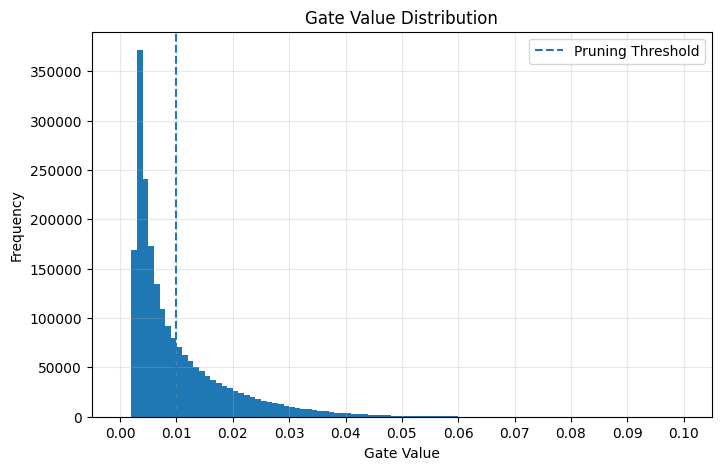

In [119]:
# =========================================================
# Step 12: Gate Value Distribution Histogram
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Collect all gate values from trained model
# ---------------------------------------------------------

all_gates = []

for module in model.modules():
    if isinstance(module, PrunableLinear):

        # Convert gate scores to gate values
        gates = torch.sigmoid(
            module.gate_scores
        ).detach().cpu().numpy()

        all_gates.extend(
            gates.flatten()
        )

all_gates = np.array(all_gates)

# ---------------------------------------------------------
# Plot histogram
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    all_gates,
    bins=100,
    range=(0, 0.1)   # zoom into important region
)

# Better x-axis ticks
ticks = np.arange(0, 0.11, 0.01)
plt.xticks(ticks)

# Optional pruning threshold line
plt.axvline(
    x=0.01,
    linestyle='--',
    label="Pruning Threshold"
)

plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Step 9: Compare Multiple Lambda Values

In [120]:
# =========================================================
# Step 9: Compare Multiple Lambda Values
# (Final Improved Version)
# =========================================================

import torch.optim as optim

# ---------------------------------------------------------
# Lambda values to compare
#
# 1e-4 → weak pruning
# 1e-3 → moderate pruning
# 1e-2 → strong pruning
# ---------------------------------------------------------

lambda_values = [1e-4, 1e-3, 1e-2]

# ---------------------------------------------------------
# Use more epochs because pruning needs time
# to fully develop
# ---------------------------------------------------------

epochs = 7

# Store final results
results = []

for lambda_val in lambda_values:

    print(f"\n===== Training with lambda = {lambda_val} =====")

    # -----------------------------------------------------
    # Create a fresh model for each lambda
    #
    # VERY IMPORTANT:
    # Never reuse old model
    # -----------------------------------------------------

    model = PrunableNet().to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    # Set training mode
    model.train()

    # -----------------------------------------------------
    # Training Loop
    # -----------------------------------------------------

    for epoch in range(epochs):

        total_loss_epoch = 0.0

        for inputs, targets in train_loader:

            # Move batch to GPU / CPU
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Clear old gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Classification loss
            cls_loss = criterion(outputs, targets)

            # Sparsity loss
            sparsity_loss = compute_sparsity_loss(model)

            # Total loss
            total_loss = (
                cls_loss
                + lambda_val * sparsity_loss
            )

            # Backpropagation
            total_loss.backward()
            optimizer.step()

            total_loss_epoch += total_loss.item()

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Loss: {total_loss_epoch:.2f}"
        )

    # -----------------------------------------------------
    # Final Evaluation
    # -----------------------------------------------------

    accuracy = evaluate(model, test_loader, device)
    sparsity = compute_sparsity(model)

    print(
        f"Lambda: {lambda_val} | "
        f"Accuracy: {accuracy:.2f}% | "
        f"Sparsity: {sparsity:.2f}%"
    )

    # Save results
    results.append(
        (lambda_val, accuracy, sparsity)
    )


===== Training with lambda = 0.0001 =====
Epoch [1/7] | Loss: 23414.03
Epoch [2/7] | Loss: 13803.98
Epoch [3/7] | Loss: 9074.56
Epoch [4/7] | Loss: 6469.25
Epoch [5/7] | Loss: 4903.42
Epoch [6/7] | Loss: 3891.85
Epoch [7/7] | Loss: 3191.88
Lambda: 0.0001 | Accuracy: 74.62% | Sparsity: 18.89%

===== Training with lambda = 0.001 =====
Epoch [1/7] | Loss: 224838.33
Epoch [2/7] | Loss: 128447.32
Epoch [3/7] | Loss: 79401.51
Epoch [4/7] | Loss: 51917.20
Epoch [5/7] | Loss: 35303.16
Epoch [6/7] | Loss: 24718.73
Epoch [7/7] | Loss: 17737.43
Lambda: 0.001 | Accuracy: 73.15% | Sparsity: 91.03%

===== Training with lambda = 0.01 =====
Epoch [1/7] | Loss: 2239481.16
Epoch [2/7] | Loss: 1276960.14
Epoch [3/7] | Loss: 786673.05
Epoch [4/7] | Loss: 511758.16
Epoch [5/7] | Loss: 345109.05
Epoch [6/7] | Loss: 238296.36
Epoch [7/7] | Loss: 167152.00
Lambda: 0.01 | Accuracy: 73.15% | Sparsity: 99.86%


# Step 11: Accuracy vs Sparsity Trade-off


LR = 0.001 | Gate Init = -1.5 | Lambda = 0.0001 | Epochs = 5
Epoch [1/5] | Loss: 23403.53
Epoch [2/5] | Loss: 13818.19
Epoch [3/5] | Loss: 9095.36
Epoch [4/5] | Loss: 6487.88
Epoch [5/5] | Loss: 4916.46

Final Accuracy : 74.19%
Final Sparsity : 0.00%


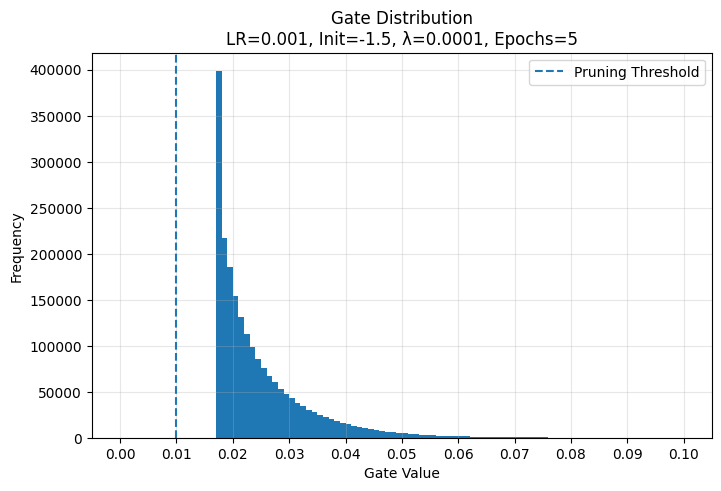


LR = 0.001 | Gate Init = -1.5 | Lambda = 0.0001 | Epochs = 10
Epoch [1/10] | Loss: 23406.30
Epoch [2/10] | Loss: 13831.02
Epoch [3/10] | Loss: 9105.40
Epoch [4/10] | Loss: 6499.80
Epoch [5/10] | Loss: 4929.32
Epoch [6/10] | Loss: 3909.39
Epoch [7/10] | Loss: 3210.69
Epoch [8/10] | Loss: 2699.53
Epoch [9/10] | Loss: 2315.07
Epoch [10/10] | Loss: 2012.29

Final Accuracy : 74.61%
Final Sparsity : 59.75%


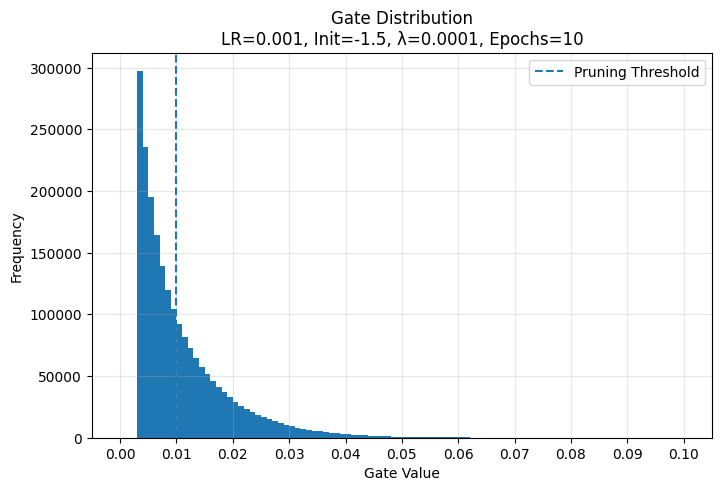


LR = 0.001 | Gate Init = -1.5 | Lambda = 0.001 | Epochs = 5
Epoch [1/5] | Loss: 224839.18
Epoch [2/5] | Loss: 128437.06
Epoch [3/5] | Loss: 79382.24
Epoch [4/5] | Loss: 51894.17
Epoch [5/5] | Loss: 35276.27

Final Accuracy : 73.62%
Final Sparsity : 0.00%


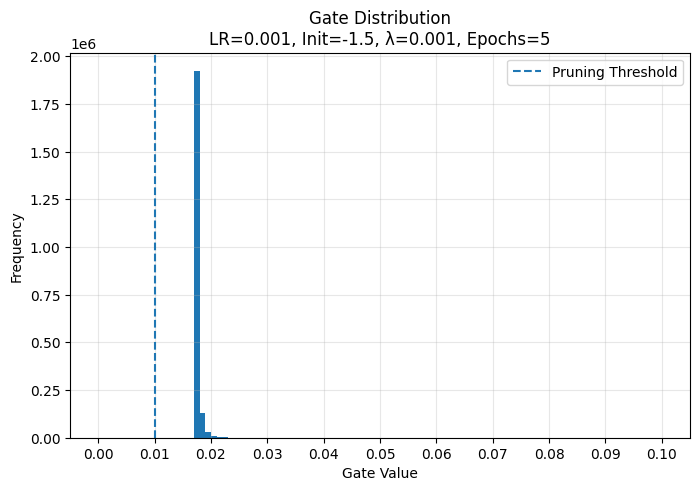


LR = 0.001 | Gate Init = -1.5 | Lambda = 0.001 | Epochs = 10
Epoch [1/10] | Loss: 224847.88
Epoch [2/10] | Loss: 128455.50
Epoch [3/10] | Loss: 79407.50
Epoch [4/10] | Loss: 51921.99
Epoch [5/10] | Loss: 35306.72
Epoch [6/10] | Loss: 24721.76
Epoch [7/10] | Loss: 17747.67
Epoch [8/10] | Loss: 13029.68
Epoch [9/10] | Loss: 9769.58
Epoch [10/10] | Loss: 7465.46

Final Accuracy : 73.37%
Final Sparsity : 99.34%


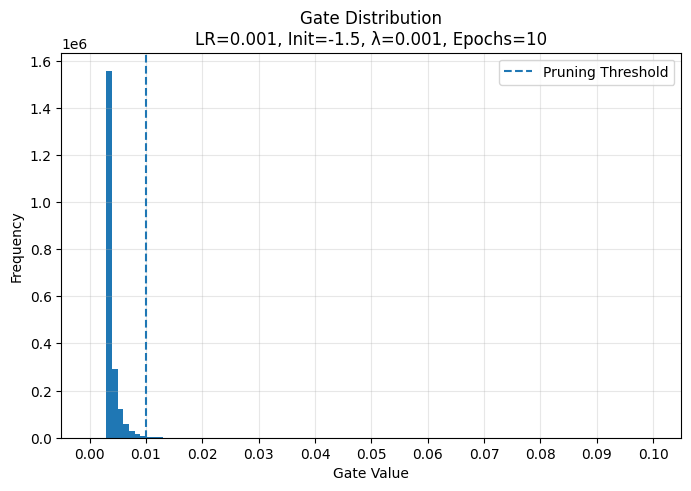


LR = 0.001 | Gate Init = -1.5 | Lambda = 0.01 | Epochs = 5
Epoch [1/5] | Loss: 2239484.30
Epoch [2/5] | Loss: 1276955.99
Epoch [3/5] | Loss: 786665.05
Epoch [4/5] | Loss: 511747.74
Epoch [5/5] | Loss: 345099.36

Final Accuracy : 73.06%
Final Sparsity : 0.00%


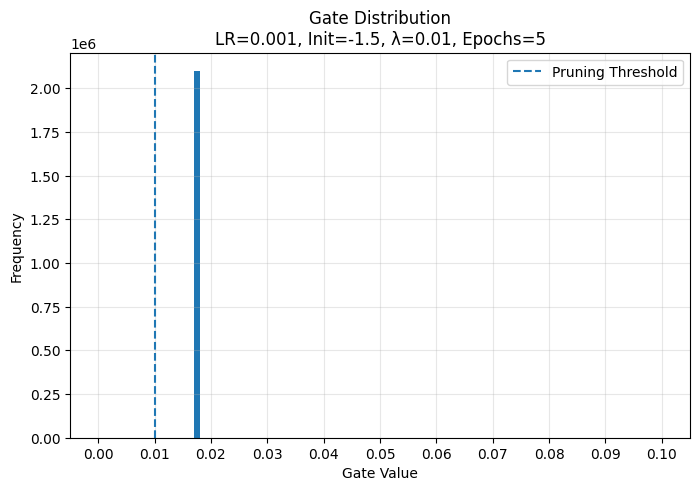


LR = 0.001 | Gate Init = -1.5 | Lambda = 0.01 | Epochs = 10
Epoch [1/10] | Loss: 2239486.15
Epoch [2/10] | Loss: 1276955.50
Epoch [3/10] | Loss: 786665.29
Epoch [4/10] | Loss: 511747.37
Epoch [5/10] | Loss: 345096.10
Epoch [6/10] | Loss: 238283.33
Epoch [7/10] | Loss: 167133.93
Epoch [8/10] | Loss: 118486.02
Epoch [9/10] | Loss: 84627.91
Epoch [10/10] | Loss: 60796.30

Final Accuracy : 71.60%
Final Sparsity : 99.95%


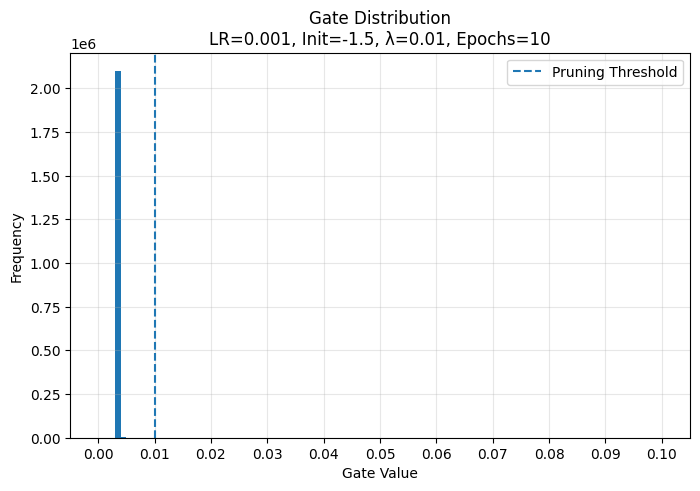


LR = 0.001 | Gate Init = -2.0 | Lambda = 0.0001 | Epochs = 5
Epoch [1/5] | Loss: 15455.22
Epoch [2/5] | Loss: 9176.93
Epoch [3/5] | Loss: 6216.69
Epoch [4/5] | Loss: 4575.37
Epoch [5/5] | Loss: 3569.82

Final Accuracy : 73.85%
Final Sparsity : 0.00%


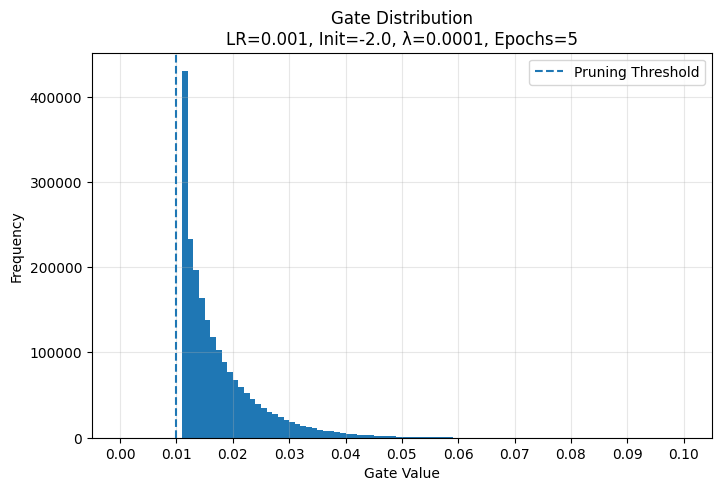


LR = 0.001 | Gate Init = -2.0 | Lambda = 0.0001 | Epochs = 10
Epoch [1/10] | Loss: 15448.33
Epoch [2/10] | Loss: 9184.00
Epoch [3/10] | Loss: 6225.40
Epoch [4/10] | Loss: 4585.58
Epoch [5/10] | Loss: 3579.11
Epoch [6/10] | Loss: 2909.08
Epoch [7/10] | Loss: 2436.40
Epoch [8/10] | Loss: 2083.57
Epoch [9/10] | Loss: 1816.23
Epoch [10/10] | Loss: 1606.85

Final Accuracy : 73.33%
Final Sparsity : 68.89%


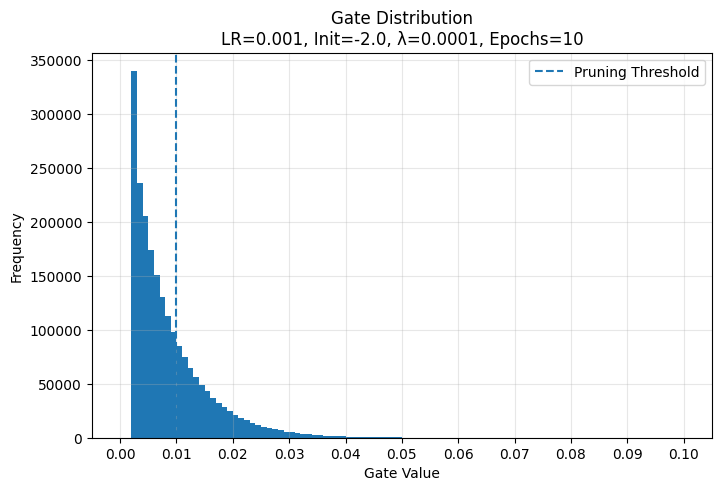


LR = 0.001 | Gate Init = -2.0 | Lambda = 0.001 | Epochs = 5
Epoch [1/5] | Loss: 145183.66
Epoch [2/5] | Loss: 82074.77
Epoch [3/5] | Loss: 50938.89
Epoch [4/5] | Loss: 33577.38
Epoch [5/5] | Loss: 23071.82

Final Accuracy : 73.22%
Final Sparsity : 0.00%


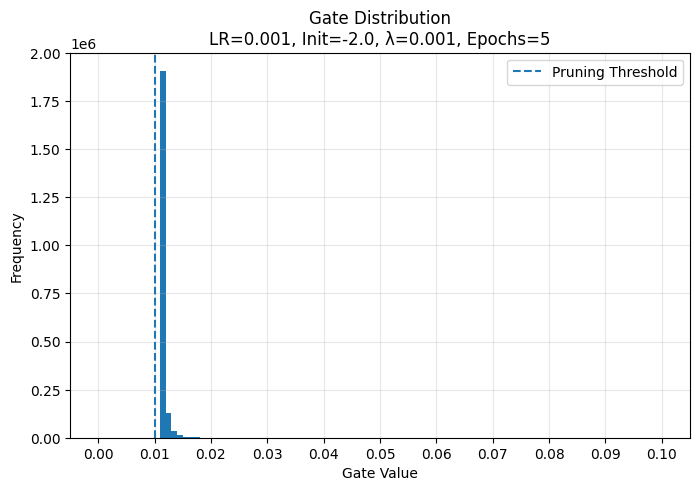


LR = 0.001 | Gate Init = -2.0 | Lambda = 0.001 | Epochs = 10
Epoch [1/10] | Loss: 145182.86
Epoch [2/10] | Loss: 82062.23
Epoch [3/10] | Loss: 50919.15
Epoch [4/10] | Loss: 33550.74
Epoch [5/10] | Loss: 23045.30
Epoch [6/10] | Loss: 16341.02
Epoch [7/10] | Loss: 11915.16
Epoch [8/10] | Loss: 8916.02
Epoch [9/10] | Loss: 6835.13
Epoch [10/10] | Loss: 5355.67

Final Accuracy : 74.01%
Final Sparsity : 99.71%


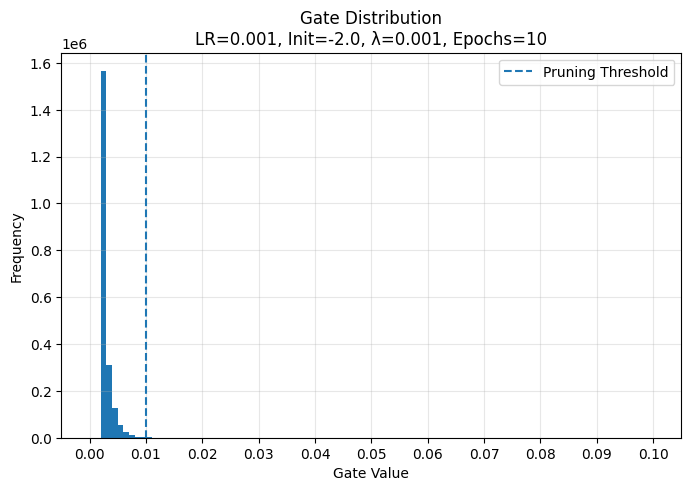


LR = 0.001 | Gate Init = -2.0 | Lambda = 0.01 | Epochs = 5
Epoch [1/5] | Loss: 1442639.03
Epoch [2/5] | Loss: 813141.43
Epoch [3/5] | Loss: 501807.57
Epoch [4/5] | Loss: 327877.94
Epoch [5/5] | Loss: 222088.70

Final Accuracy : 71.80%
Final Sparsity : 0.00%


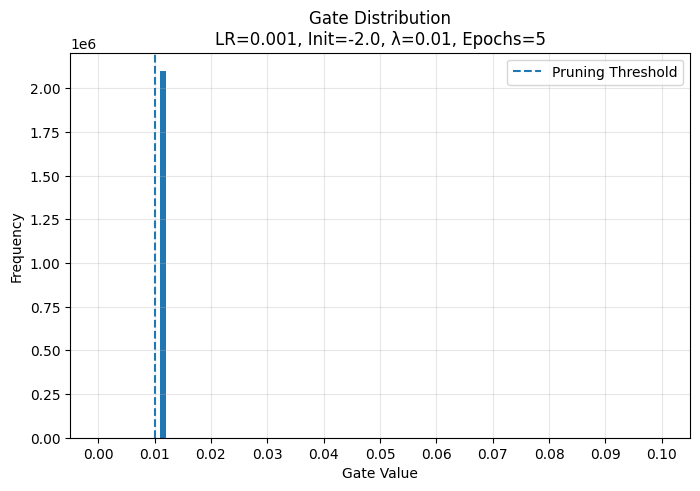


LR = 0.001 | Gate Init = -2.0 | Lambda = 0.01 | Epochs = 10
Epoch [1/10] | Loss: 1442640.24
Epoch [2/10] | Loss: 813127.20
Epoch [3/10] | Loss: 501791.53
Epoch [4/10] | Loss: 327859.68
Epoch [5/10] | Loss: 222073.09
Epoch [6/10] | Loss: 153939.60
Epoch [7/10] | Loss: 108351.48
Epoch [8/10] | Loss: 77065.16
Epoch [9/10] | Loss: 55237.30
Epoch [10/10] | Loss: 39848.54

Final Accuracy : 71.57%
Final Sparsity : 99.96%


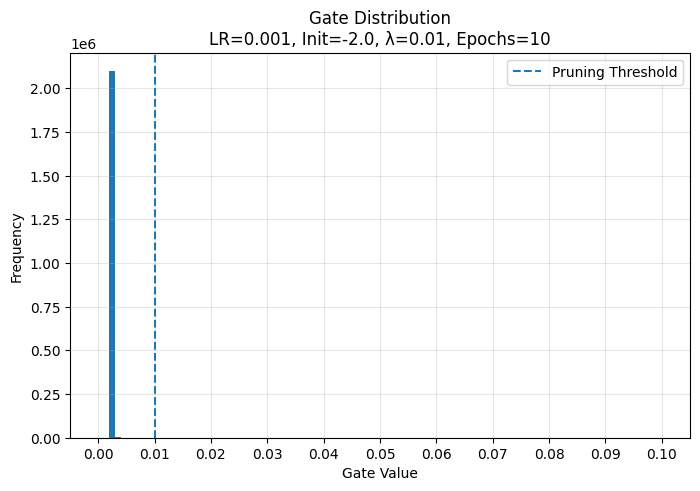

In [121]:
# =========================================================
# Step 14: Hyperparameter Search and Plotting
# + Accuracy + Sparsity + Gate Histogram
# =========================================================

import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Hyperparameter search space
# ---------------------------------------------------------

learning_rates = [1e-3]
gate_init_values = [-1.5, -2.0]
lambda_values = [1e-4, 1e-3,1e-2]
epochs_list = [5, 10]

# Store results
experiment_results = []


# =========================================================
# Run Experiments
# =========================================================

for lr in learning_rates:
    for gate_init in gate_init_values:
        for lambda_val in lambda_values:
            for epochs in epochs_list:

                print("\n" + "=" * 70)
                print(
                    f"LR = {lr} | "
                    f"Gate Init = {gate_init} | "
                    f"Lambda = {lambda_val} | "
                    f"Epochs = {epochs}"
                )
                print("=" * 70)

                # -------------------------------------------------
                # Fresh model
                # -------------------------------------------------

                model = PrunableNet().to(device)

                # Reset gate scores manually
                for module in model.modules():
                    if isinstance(module, PrunableLinear):
                        module.gate_scores.data.fill_(gate_init)

                optimizer = optim.Adam(
                    model.parameters(),
                    lr=lr
                )

                # -------------------------------------------------
                # Training
                # -------------------------------------------------

                model.train()

                for epoch in range(epochs):

                    total_loss_epoch = 0.0

                    for inputs, targets in train_loader:

                        inputs = inputs.to(device)
                        targets = targets.to(device)

                        optimizer.zero_grad()

                        outputs = model(inputs)

                        cls_loss = criterion(outputs, targets)
                        sparsity_loss = compute_sparsity_loss(model)

                        total_loss = (
                            cls_loss
                            + lambda_val * sparsity_loss
                        )

                        total_loss.backward()
                        optimizer.step()

                        total_loss_epoch += total_loss.item()

                    print(
                        f"Epoch [{epoch + 1}/{epochs}] | "
                        f"Loss: {total_loss_epoch:.2f}"
                    )

                # -------------------------------------------------
                # Evaluation
                # -------------------------------------------------

                accuracy = evaluate(
                    model,
                    test_loader,
                    device
                )

                sparsity = compute_sparsity(model)

                print(
                    f"\nFinal Accuracy : {accuracy:.2f}%"
                )
                print(
                    f"Final Sparsity : {sparsity:.2f}%"
                )

                # Save results
                experiment_results.append([
                    lr,
                    gate_init,
                    lambda_val,
                    epochs,
                    accuracy,
                    sparsity
                ])

                # -------------------------------------------------
                # Gate Histogram Plot
                # -------------------------------------------------

                all_gates = []

                for module in model.modules():
                    if isinstance(module, PrunableLinear):

                        gates = torch.sigmoid(
                            module.gate_scores
                        ).detach().cpu().numpy()

                        all_gates.extend(
                            gates.flatten()
                        )

                all_gates = np.array(all_gates)

                plt.figure(figsize=(8, 5))

                plt.hist(
                    all_gates,
                    bins=100,
                    range=(0, 0.1)
                )

                # Threshold line
                plt.axvline(
                    x=0.01,
                    linestyle='--',
                    label="Pruning Threshold"
                )

                # Better x-axis ticks
                ticks = np.arange(0, 0.11, 0.01)
                plt.xticks(ticks)

                plt.title(
                    f"Gate Distribution\n"
                    f"LR={lr}, Init={gate_init}, "
                    f"λ={lambda_val}, Epochs={epochs}"
                )

                plt.xlabel("Gate Value")
                plt.ylabel("Frequency")
                plt.legend()
                plt.grid(alpha=0.3)

                plt.show()